In [3]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

## Defining Differential Equation

In [ ]:
def pde(x, u):
    return -1*dde.grad.hessian(u, x) - 1

geom = dde.geometry.Interval(-1, 1)


bc = dde.icbc.DirichletBC(
    geom, 
    lambda x : 0,
    lambda x, on_boundary: on_boundary
)


data = dde.data.PDE(
    geom, 
    pde, 
    [bc],
    num_domain=100,
    num_boundary=2,
    solution=lambda x: (1 - x**2) / 2
)

net = dde.nn.FNN(
    [1] + [32]*3 + [1],
    "tanh",
    "Glorot normal"
)

model = dde.Model(data, net)

model.compile("adam", lr=0.001)

loss, stats = model.train(iterations=1000, display_every=100)

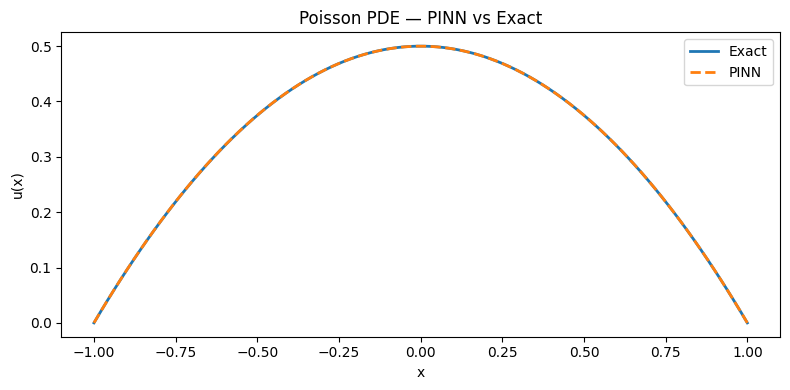

In [7]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-1, 1, 100)
xx, yy = np.meshgrid(x, y)

# The trained PDE is 1D, so this makes a 2D view by repeating u(x) along y.
x_test = xx.ravel()[:, None]
solution = model.predict(x_test).reshape(xx.shape)
exact = (1 - xx**2) / 2
error = np.abs(exact - solution)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

plots = [
    (exact, "Exact solution"),
    (solution, "PINN solution"),
    (error, "Absolute error"),
]

for ax, (values, title) in zip(axes, plots):
    contour = ax.contourf(xx, yy, values, levels=50, cmap="viridis")
    fig.colorbar(contour, ax=ax, label="u(x)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

fig.suptitle("2D view of the 1D Poisson PINN")
plt.show()